# 02 - Visualization: Predicting Developer Sentiment Toward AI
**Target (y):** `AI_Sentiment_Score` (0, 25, 50, 75, 100) | **Data:** `data/processed/02_manipulated.csv` (current AI users)

Regression route from the Data Visualization Handbook: target distribution -> correlation heatmap -> regplot -> pairplot (no hue) -> boxplot -> categorical predictors.
`residplot` is skipped: no model is fitted yet (it belongs to the modeling teammate).

**How to use:** run the cells top to bottom (Shift+Enter). Each chart is saved to `figures/` and shown below its cell.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA = Path("data/processed/02_manipulated.csv")   # run the notebook from the project folder
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

TARGET = "AI_Sentiment_Score"
NUMERIC = ["AI_Trust_Score", "ai_complex_task_concern", "AI_Benefit_Breadth",
           "AI_Tool_Count", "years_professional_coding_num"]
CATEGORICAL = ["country", "organization_size", "education_level"]

sns.set_theme(style="whitegrid", context="notebook")
TEAL, ORANGE, GREY = "#1f7a72", "#e07b39", "#6b7280"


def save(fig, name):
    """Save the chart as a PNG in figures/ and show it here."""
    fig.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")
    plt.show()
    print("saved", name)

## 0. Load the data and take a first look

In [2]:
df = pd.read_csv(DATA)
print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (37536, 11)


,respondent_id,AI_Sentiment_Score,AI_Trust_Score,ai_complex_task_concern,AI_Benefit_Breadth,AI_Tool_Count,years_professional_coding_num,country,organization_size,education_level,sentiment_label
0,SO24_00000001,100.0,NaN,NaN,1.0,0.0,NaN,United States of America,NaN,code_4,Very favourable
1,SO24_00000004,100.0,75.0,2.0,5.0,8.0,NaN,Canada,NaN,code_7,Very favourable
2,SO24_00000006,75.0,75.0,4.0,3.0,2.0,NaN,United States of America,NaN,code_4,Favourable
3,SO24_00000008,50.0,25.0,2.0,3.0,3.0,NaN,Other,NaN,code_6,Indifferent/unsure
4,SO24_00000010,50.0,50.0,2.0,2.0,1.0,11.0,Other,NaN,code_3,Indifferent/unsure


### Missing values
Missing values are still in this file on purpose (they are filled later, for the model only). Seaborn drops them chart by chart, so each chart can use a slightly different number of rows.

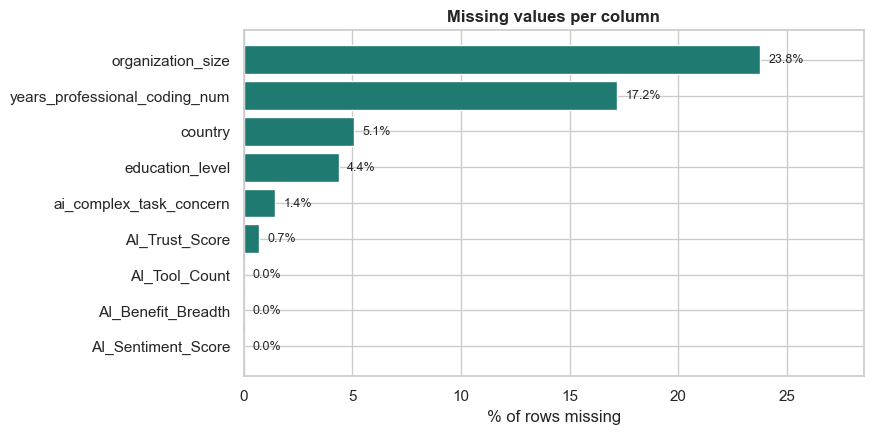

saved fig_00_missing_values.png


In [3]:
miss = (df[[TARGET] + NUMERIC + CATEGORICAL].isna().mean() * 100).sort_values()
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(miss.index, miss.values, color=TEAL)
for i, v in enumerate(miss.values):
    ax.text(v + 0.4, i, f"{v:.1f}%", va="center", fontsize=9)
ax.set_xlabel("% of rows missing")
ax.set_title("Missing values per column", fontweight="bold")
ax.set_xlim(0, miss.max() * 1.2)
save(fig, "fig_00_missing_values.png")

## 1. Target distribution: is `AI_Sentiment_Score` skewed?
*Skewed* means most values bunch up on one side with a tail on the other. The handbook says a skewed target may need a transform (for example a log).

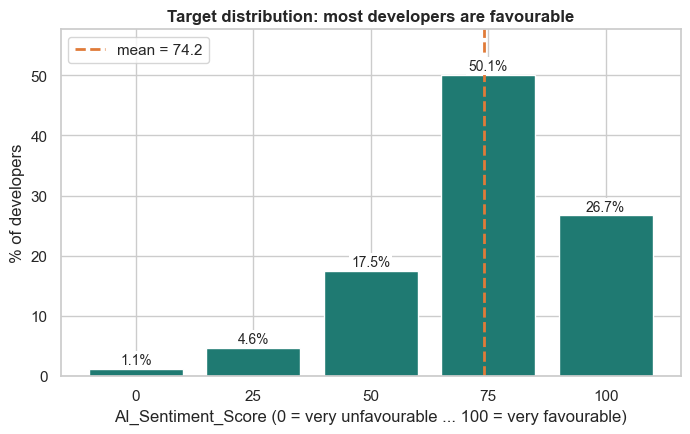

saved fig_01_target_distribution.png
skewness: -0.82 (negative = tail to the left)


In [4]:
order = [0, 25, 50, 75, 100]
share = df[TARGET].value_counts(normalize=True).reindex(order) * 100
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar([str(o) for o in order], share.values, color=TEAL)
for b, v in zip(bars, share.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.8, f"{v:.1f}%", ha="center", fontsize=10,
            zorder=5, bbox={"fc": "white", "ec": "none", "pad": 1.5})
ax.axvline(x=df[TARGET].mean() / 25, color=ORANGE, ls="--", lw=2,
           label=f"mean = {df[TARGET].mean():.1f}")
ax.legend(loc="upper left", frameon=True)
ax.set_xlabel("AI_Sentiment_Score (0 = very unfavourable ... 100 = very favourable)")
ax.set_ylabel("% of developers")
ax.set_title("Target distribution: most developers are favourable", fontweight="bold")
ax.set_ylim(0, share.max() * 1.15)
save(fig, "fig_01_target_distribution.png")
print("skewness:", round(df[TARGET].skew(), 2), "(negative = tail to the left)")

**What it reveals:** about 77% score 75 or 100, only about 6% score 0 or 25, mean about 74. The skew comes from a ceiling at 100, not a long tail, and the score includes 0, so a log transform does not fit. A "always predict the average" model already sits at 74, which is the baseline to beat.

## 2. Correlation heatmap: which predictors move with sentiment?
*Correlation (r)* is a number from -1 to +1: how closely two columns rise and fall together. 0 means no link. The heatmap also shows which *predictors* overlap with each other (*multicollinearity*), which matters because linear regression gives each predictor its own coefficient.

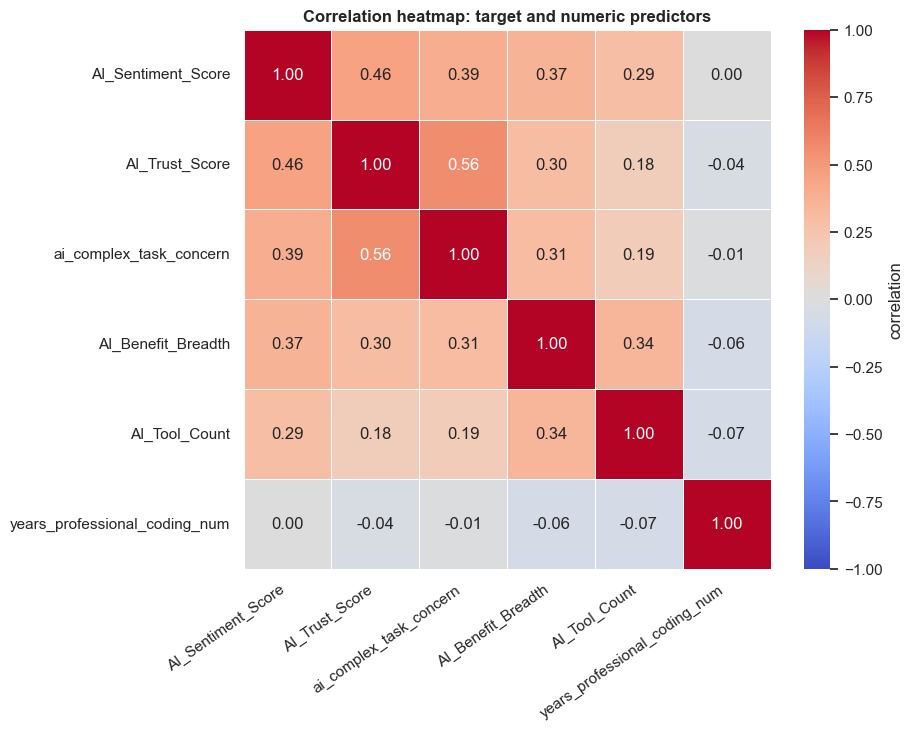

saved fig_02_correlation_heatmap.png


AI_Trust_Score                   0.46
ai_complex_task_concern          0.39
AI_Benefit_Breadth               0.37
AI_Tool_Count                    0.29
years_professional_coding_num    0.00
Name: AI_Sentiment_Score, dtype: float64

In [5]:
corr = df[[TARGET] + NUMERIC].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={"label": "correlation"}, ax=ax)
ax.set_title("Correlation heatmap: target and numeric predictors", fontweight="bold")
plt.setp(ax.get_xticklabels(), rotation=35, ha="right")
save(fig, "fig_02_correlation_heatmap.png")
corr[TARGET].drop(TARGET).sort_values(ascending=False).round(2)

**What it reveals:** trust (0.46) > complex-task rating (0.39) > benefits (0.37) > tool count (0.29) > years of coding (0.00). The biggest overlap between two predictors is trust vs complex-task rating (0.56).

## 3. regplot: is each relationship a straight line?
Linear regression assumes straight lines, so this tests that assumption.
- **Orange line** = the straight-line fit.
- **Dark dots** = the real average sentiment at each value of the predictor.
- **Grey dots** = respondents, nudged slightly (*jitter*) so whole-number values do not stack on top of each other.

If the dark dots follow the orange line, a straight line is fine. If they bend away, it is not.

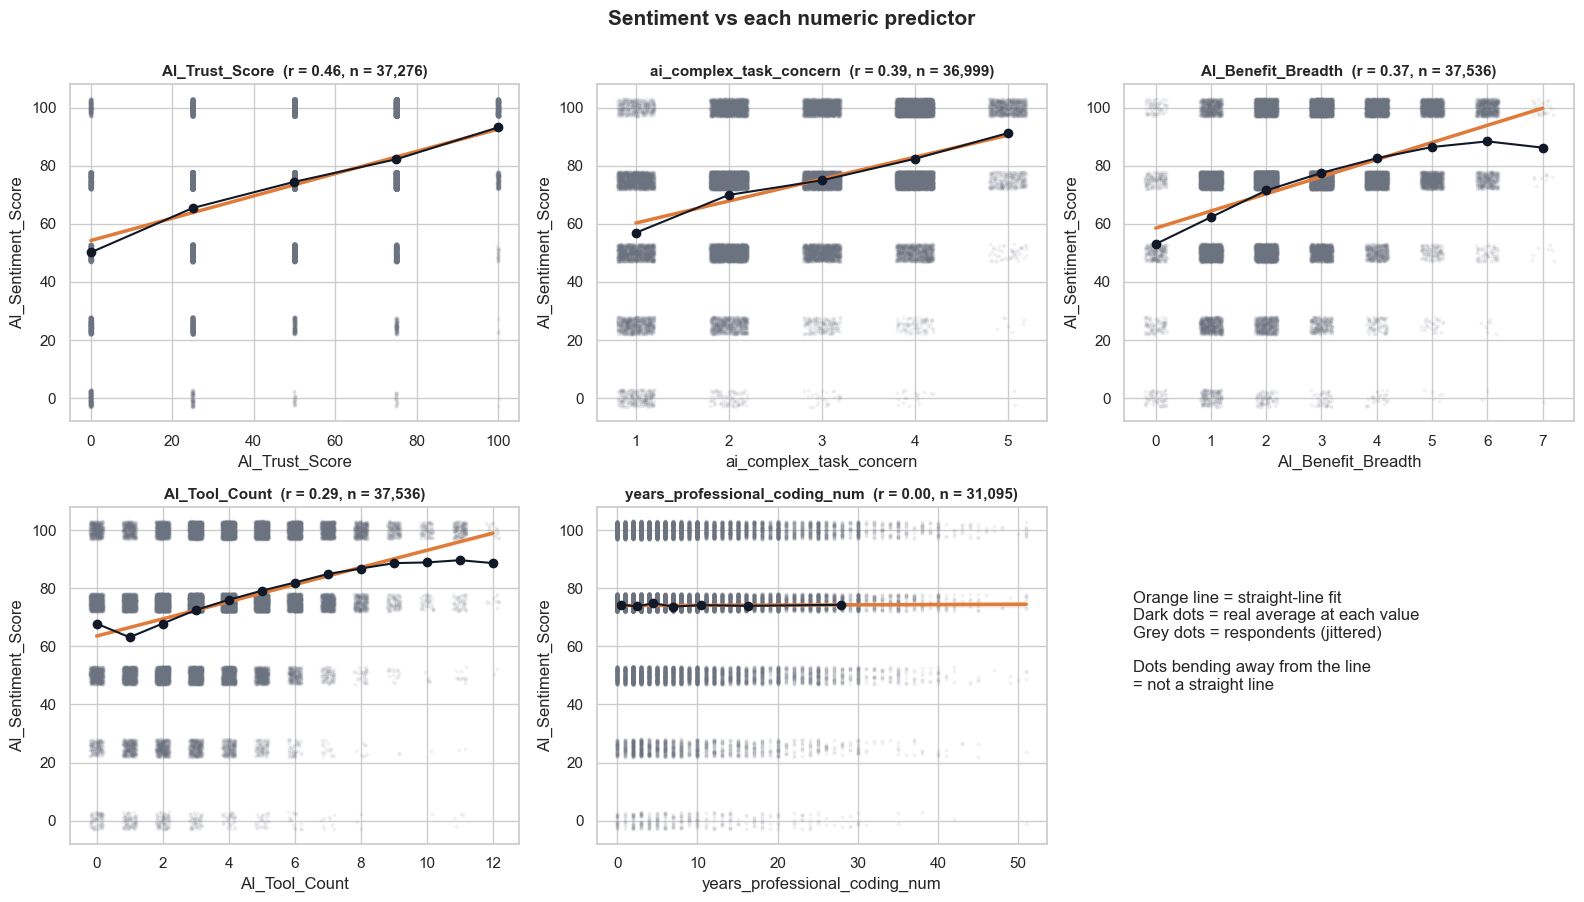

saved fig_03_regplots.png


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()
for ax, col in zip(axes, NUMERIC):
    sub = df[[col, TARGET]].dropna()
    sns.regplot(data=sub, x=col, y=TARGET, ax=ax,
                x_jitter=0.2 if col != "years_professional_coding_num" else 0,
                y_jitter=3,
                scatter_kws={"s": 4, "alpha": 0.06, "color": GREY},
                line_kws={"color": ORANGE, "lw": 2.5})
    if col == "years_professional_coding_num":          # too many values: group them
        sub = sub.assign(b=pd.cut(sub[col], [-1, 1, 3, 5, 8, 12, 20, 60]))
        g = sub.groupby("b", observed=True).agg(x=(col, "mean"), mean=(TARGET, "mean"))
        ax.plot(g["x"], g["mean"], "o-", color="#111827", ms=6, lw=1.5)
    else:
        means = sub.groupby(col)[TARGET].agg(["mean", "count"])
        means = means[means["count"] >= 30]             # skip tiny groups
        ax.plot(means.index, means["mean"], "o-", color="#111827", ms=6, lw=1.5)
    r = sub[col].corr(sub[TARGET])
    ax.set_title(f"{col}  (r = {r:.2f}, n = {len(sub):,})", fontsize=11, fontweight="bold")
    ax.set_ylabel("AI_Sentiment_Score")
    ax.set_ylim(-8, 108)
axes[-1].axis("off")
axes[-1].text(0.02, 0.6,
              "Orange line = straight-line fit\nDark dots = real average at each value\n"
              "Grey dots = respondents (jittered)\n\nDots bending away from the line\n= not a straight line",
              fontsize=12, va="center")
fig.suptitle("Sentiment vs each numeric predictor", fontsize=15, fontweight="bold", y=1.0)
fig.tight_layout()
save(fig, "fig_03_regplots.png")

**What it reveals:**
- **Trust** is almost perfectly straight (average sentiment 50 -> 65 -> 75 -> 82 -> 93).
- **Complex-task rating** is close to straight (57 -> 91).
- **Benefits** rises, then levels off above 5 (the 7-benefit group has only 49 people, so ignore its small drop).
- **Tool count** rises overall but *dips* at the low end: 0 tools averages 67.8, 1 tool averages 63.1. Not a clean straight line there.
- **Years of coding** is flat (r = 0.00).

## 4. pairplot (no hue): every distribution and every pairwise trend at once
Uses a 2,000-row sample (all 37,536 points would be unreadable). Jitter is for display only; the histograms on the diagonal use the real values.

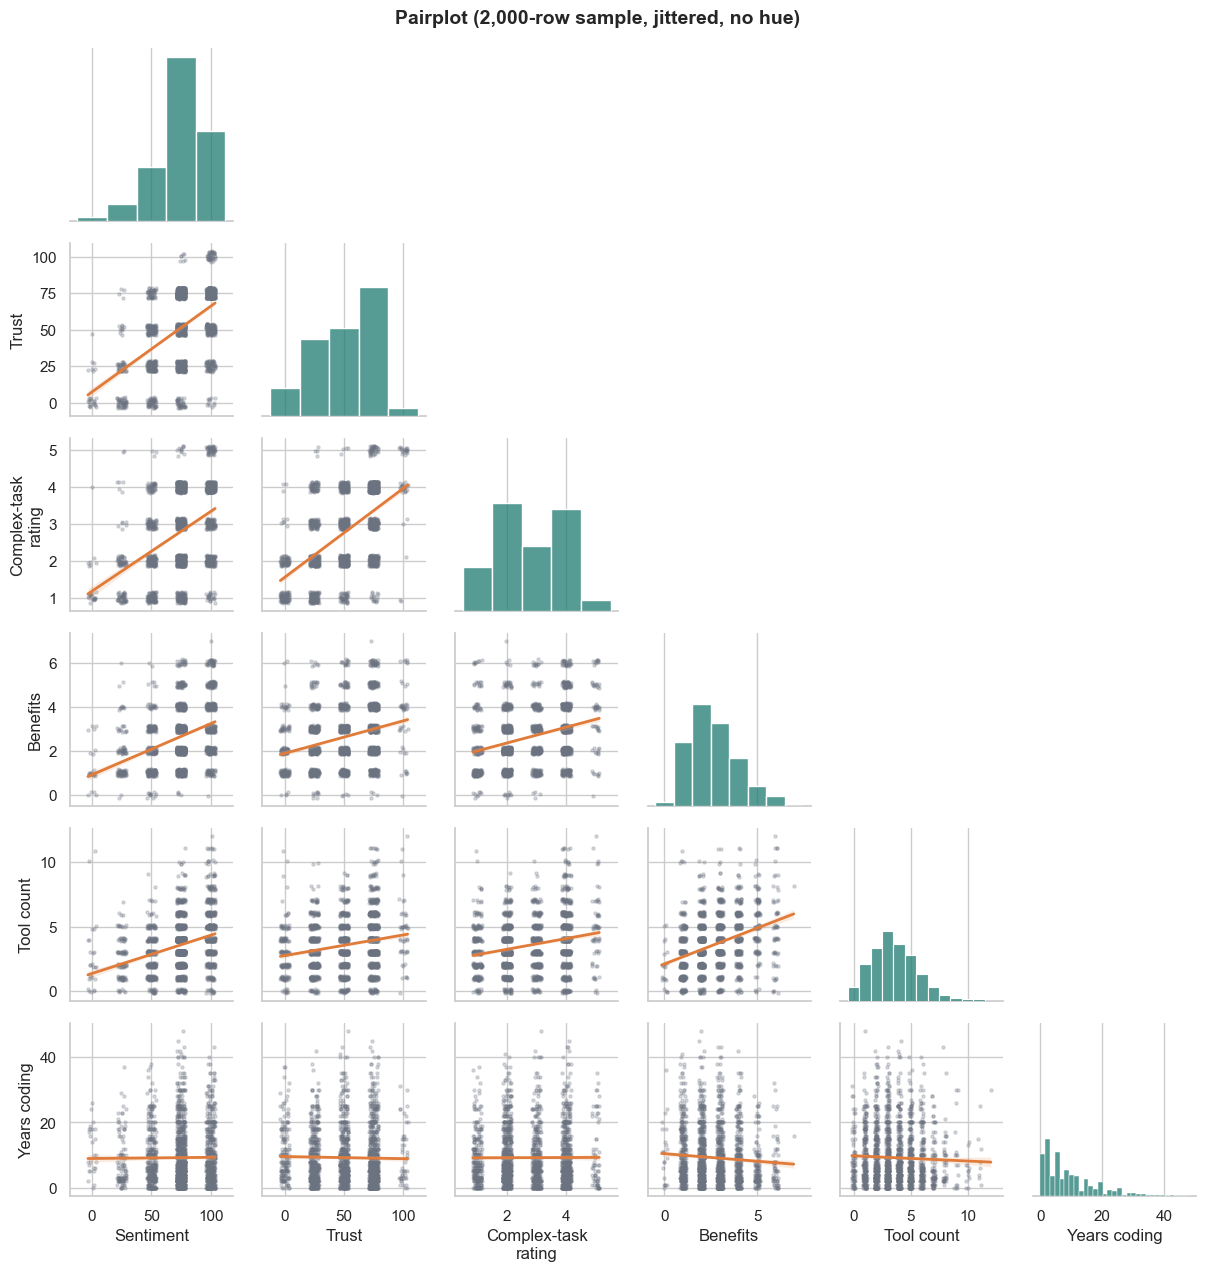

saved fig_04_pairplot.png


In [7]:
rng = np.random.default_rng(42)
cols = [TARGET] + NUMERIC
short_names = {TARGET: "Sentiment", "AI_Trust_Score": "Trust",
               "ai_complex_task_concern": "Complex-task\nrating", "AI_Benefit_Breadth": "Benefits",
               "AI_Tool_Count": "Tool count", "years_professional_coding_num": "Years coding"}
raw = df[cols].dropna().sample(2000, random_state=42).rename(columns=short_names)
jit = raw.copy()
for c in jit.columns:                                   # jitter for display only
    if c != "Years coding":
        step = 25 if c in ("Sentiment", "Trust") else 1
        jit[c] = jit[c] + rng.uniform(-0.15, 0.15, len(jit)) * step


def diag_hist(x, **kw):                                  # histogram from the REAL values
    r = raw.loc[x.index, x.name]
    if x.name in ("Sentiment", "Trust"):                 # these step by 25
        sns.histplot(r, binwidth=25, binrange=(-12.5, 112.5), color=TEAL, ax=plt.gca())
    else:
        sns.histplot(r, discrete=(x.name != "Years coding"), color=TEAL, ax=plt.gca())


def lower_reg(x, y, **kw):
    sns.regplot(x=x, y=y, ax=plt.gca(), scatter_kws={"s": 5, "alpha": 0.25, "color": GREY},
                line_kws={"color": ORANGE, "lw": 2})


g = sns.PairGrid(jit, corner=True, height=2.1)
g.map_diag(diag_hist)
g.map_lower(lower_reg)
g.figure.suptitle("Pairplot (2,000-row sample, jittered, no hue)", y=1.01,
                  fontsize=14, fontweight="bold")
save(g.figure, "fig_04_pairplot.png")

**What it reveals:** the same rising lines for the four AI predictors, a flat line for years of coding, and the link between trust and complex-task rating, all in one picture.

## 5. Boxplots: any extreme values left after cleaning?
The box covers the middle half of the data; dots beyond the whiskers are *outliers* (unusually extreme values).

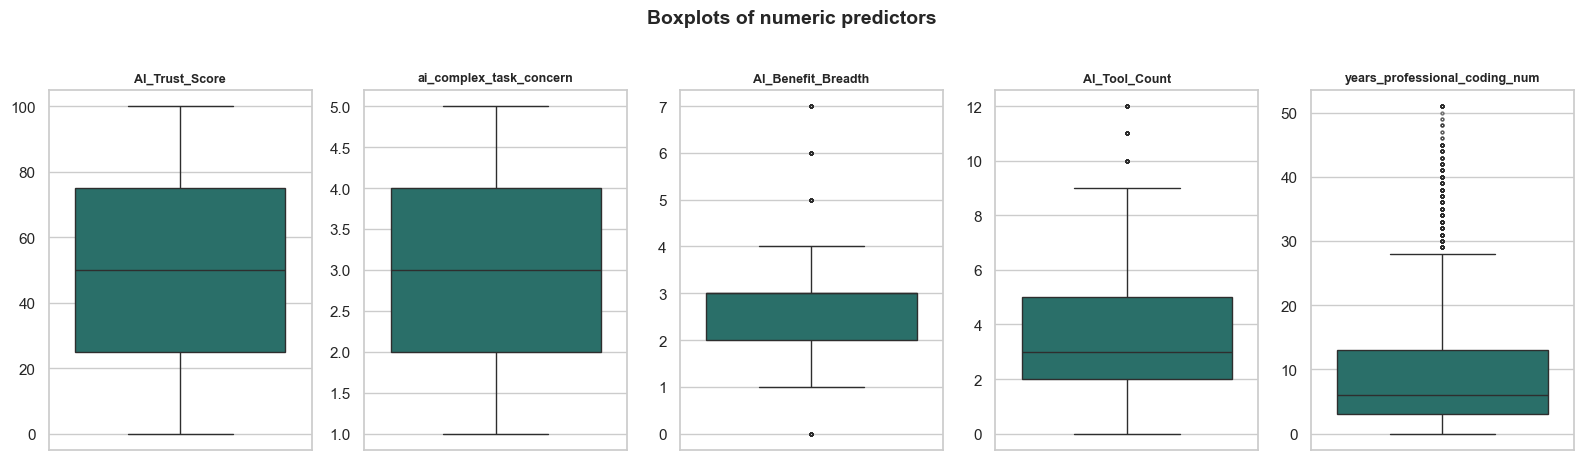

saved fig_05_boxplots.png
people with more than 30 years of coding: 753


In [8]:
fig, axes = plt.subplots(1, 5, figsize=(16, 4.5))
for ax, col in zip(axes, NUMERIC):
    sns.boxplot(y=df[col].dropna(), ax=ax, color=TEAL, fliersize=2, flierprops={"alpha": 0.4})
    ax.set_title(col, fontsize=9, fontweight="bold")
    ax.set_ylabel("")
fig.suptitle("Boxplots of numeric predictors", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
save(fig, "fig_05_boxplots.png")
print("people with more than 30 years of coding:", int((df["years_professional_coding_num"] > 30).sum()))

**What it reveals:** no impossible values (nothing below 0 or past the scale). Years of coding has a long upper tail (up to 51 years), which is plausible, not an error. Nothing needs removing.

## 6. Categorical predictors: do groups differ in sentiment?
Bars show the average sentiment per group with a 95% confidence interval (the thin line: the range the true average probably sits in). The dashed line is the overall mean.
`organization_size` and `education_level` are **codes**, and their real meanings are not in the dataset, so we do not guess them. Missing answers get their own orange bar. The axis starts at 40, which makes gaps look bigger than they are.

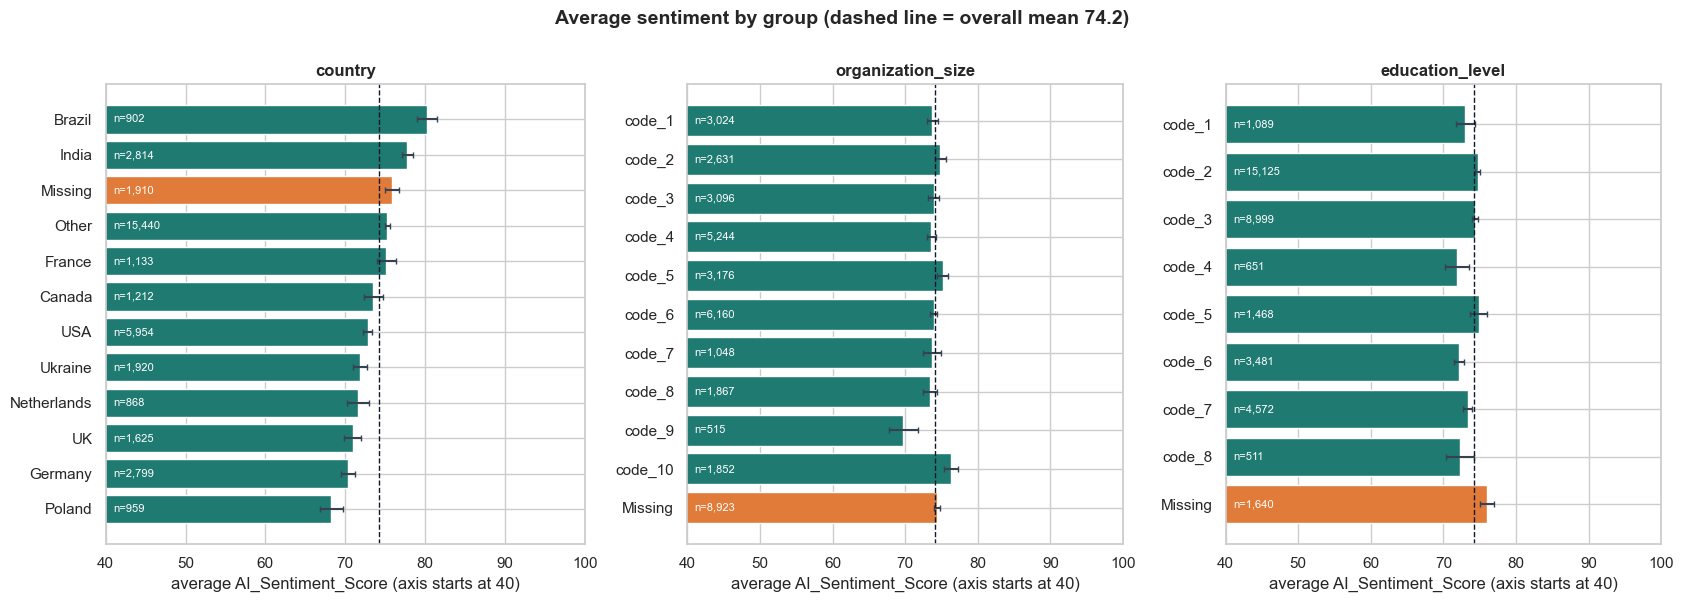

saved fig_06_categorical_predictors.png


In [9]:
overall = df[TARGET].mean()
short = {"United Kingdom of Great Britain and Northern Ireland": "UK",
         "United States of America": "USA"}
fig, axes = plt.subplots(1, 3, figsize=(17, 6), gridspec_kw={"width_ratios": [1.1, 1, 1]})
for ax, col in zip(axes, CATEGORICAL):
    t = df[[col, TARGET]].copy()
    t[col] = t[col].fillna("Missing").replace(short)
    g = t.groupby(col)[TARGET].agg(["mean", "std", "count"])
    g["ci"] = 1.96 * g["std"] / np.sqrt(g["count"])
    if col == "country":
        g = g.sort_values("mean")
    else:                                              # code_1, code_2 ... code_10
        key = g.index.map(lambda s: int(s.split("_")[1]) if s.startswith("code_") else 99)
        g = g.iloc[np.argsort(key)]
    colors = [ORANGE if i == "Missing" else TEAL for i in g.index]
    ax.barh(g.index, g["mean"], xerr=g["ci"], color=colors, ecolor="#374151", capsize=2)
    ax.axvline(overall, color="#111827", ls="--", lw=1)
    for i, n in enumerate(g["count"]):
        ax.text(41, i, f"n={n:,}", va="center", fontsize=8, color="white")
    ax.set_xlim(40, 100)
    if col != "country":
        ax.invert_yaxis()                              # code_1 at the top
    ax.set_xlabel("average AI_Sentiment_Score (axis starts at 40)")
    ax.set_title(col, fontweight="bold")
fig.suptitle(f"Average sentiment by group (dashed line = overall mean {overall:.1f})",
             fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
save(fig, "fig_06_categorical_predictors.png")

**What it reveals:** country ranges from Poland (68.2) to Brazil (80.2), about 12 points. Organization size and education sit mostly within 70-76. So "background matters little" mostly holds, with country as the exception.

## Wrap-up: do the debrief's expectations hold?
| Expectation | Verdict |
|---|---|
| More trust, more favourable | Holds, strongest predictor (r = 0.46) |
| Better complex-task rating, more favourable | Holds (r = 0.39) |
| More benefits, more favourable | Holds, levels off above 5 (r = 0.37) |
| More AI uses, more favourable | Holds overall (r = 0.29), but dips at 0-1 uses |
| Years of coding: no clear link | Holds exactly (r = 0.00) |
| Country / org size / education: small differences | Mostly holds; country spreads about 12 points |

**Surprises:** the dip at 0-1 tools (6.6% of "AI users" report 0 tools, reason unknown, ask the data-prep owner); trust and complex-task rating overlap (r = 0.56).
Not done here: `residplot` (needs a fitted model).